In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


## What we will do in this project?

We will doing some sentiment analysis in python using two different technoques.
1. VADAR(Valence Aware Dictionary and Sentiment Reasoner) - Bag of Words.
2. Roberta Pretrained Model from Huggingface🤗.
3. Huggingface Pipeline.

## Project Workflow
1. Setup & Data Ingestion
2. EDA (Exploratory Data Analysis)
3. Lexicon-Based Sentiment Analysis (NLTK VADER)
4. Deep Learning Sentiment Analysis (Hugging Face RoBERTa)
5. Model Comparison & Evaluation

# Setup & Data Ingestion 

# Import libraries 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import nltk

from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud

plt.style.use('ggplot')

# Load data 

In [3]:
# Read the data 
data = pd.read_csv('/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
data.shape

(568454, 10)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


# EDA (Exploratoty Data Analysis)

In [6]:
data['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

### Ratings & Sentiment

In [7]:
# ── Colors & Global Settings ───────────────────────────────
C = {"Positive":"#4CAF50", "Neutral":"#FF9800", "Negative":"#F44336", "bar":"#5C85D6"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

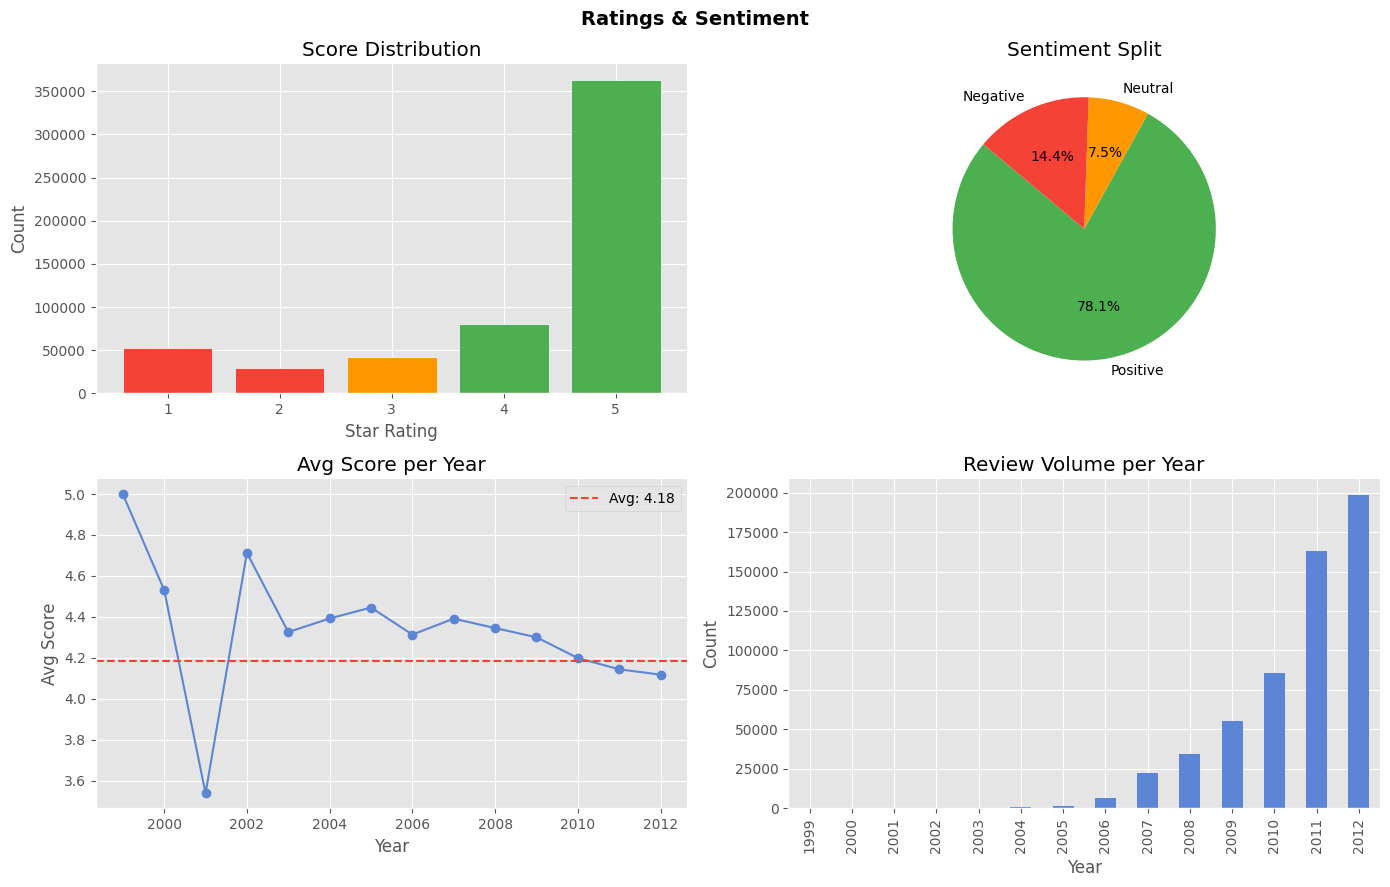

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Ratings & Sentiment", fontsize=14, fontweight="bold")

# 1. Score Distribution (Directly from 'Score')
ax = axes[0,0]
counts = data["Score"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=[C["Negative"],C["Negative"],C["Neutral"],C["Positive"],C["Positive"]], edgecolor="white")
ax.set(title="Score Distribution", xlabel="Star Rating", ylabel="Count")


# 2. Sentiment Split (On-the-fly mapping)
ax = axes[0,1]
sentiment_series = data["Score"].map({1:"Negative", 2:"Negative", 3:"Neutral", 4:"Positive", 5:"Positive"})
s_counts = sentiment_series.value_counts().reindex(["Positive","Neutral","Negative"])
ax.pie(s_counts, labels=s_counts.index, autopct="%1.1f%%", colors=[C["Positive"],C["Neutral"],C["Negative"]], startangle=140)
ax.set_title("Sentiment Split")


# 3. Avg Score per Year (On-the-fly date conversion)
ax = axes[1,0]
temp_years = pd.to_datetime(data["Time"], unit="s").dt.year
yr_avg = data.groupby(temp_years)["Score"].mean()
ax.plot(yr_avg.index, yr_avg.values, marker="o", color=C["bar"])
ax.axhline(data["Score"].mean(), color=C["Negative"], linestyle="--", label=f"Avg: {data['Score'].mean():.2f}")
ax.set(title="Avg Score per Year", xlabel="Year", ylabel="Avg Score"); ax.legend()


# 4. Review Volume per Year
ax = axes[1,1]
temp_years.value_counts().sort_index().plot(kind='bar', ax=ax, color=C["bar"])
ax.set(title="Review Volume per Year", xlabel="Year", ylabel="Count")

plt.tight_layout()
plt.show()

### Text Analysis 

/tmp/ipykernel_23/1903195836.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=sentiment_series, y=word_counts, order=["Positive","Neutral","Negative"],


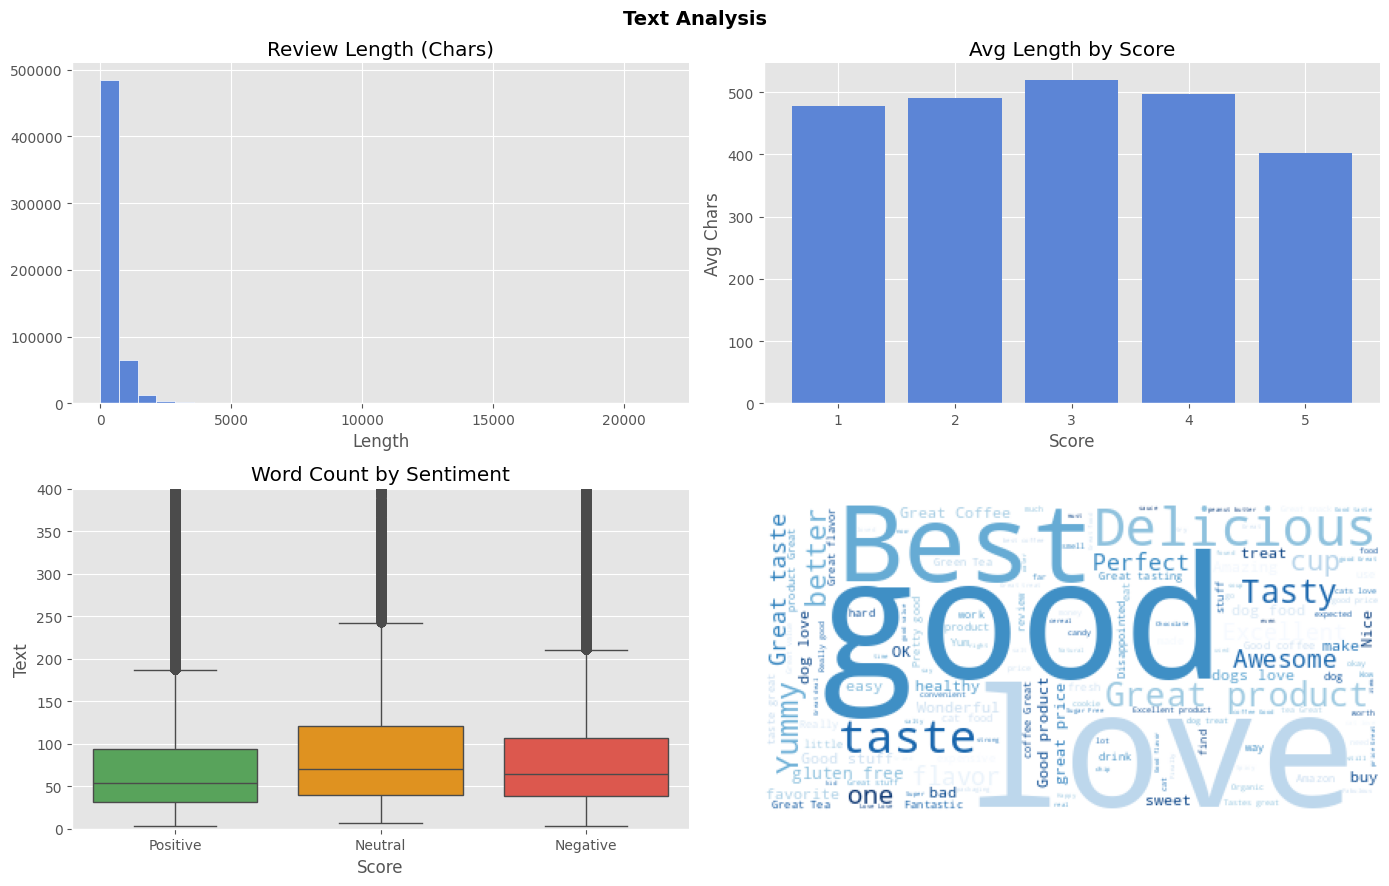

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Text Analysis", fontsize=14, fontweight="bold")

# 1. Review Length Distribution
ax = axes[0,0]
lengths = data["Text"].str.len()
ax.hist(lengths, bins=30, color=C["bar"], edgecolor="white")
ax.set(title="Review Length (Chars)", xlabel="Length")



# 2. Avg Review Length by Score
ax = axes[0,1]
avg_len_by_score = lengths.groupby(data["Score"]).mean()
ax.bar(avg_len_by_score.index, avg_len_by_score.values, color=C["bar"])
ax.set(title="Avg Length by Score", xlabel="Score", ylabel="Avg Chars")



# 3. Word Count by Sentiment (Boxplot)
ax = axes[1,0]
# We calculate word counts locally for the plot
word_counts = data["Text"].apply(lambda x: len(str(x).split()))
sns.boxplot(x=sentiment_series, y=word_counts, order=["Positive","Neutral","Negative"], 
            palette=[C["Positive"], C["Neutral"], C["Negative"]], ax=ax)
ax.set(title="Word Count by Sentiment", ylim=(0, 400)) # Limiting y-axis for visibility



# 4. WordCloud
ax = axes[1,1]
wc = WordCloud(background_color="white", colormap="Blues").generate(" ".join(data["Summary"].dropna()))
ax.imshow(wc); ax.axis("off")

plt.tight_layout()
plt.show()

### Helpfulness & Correlations

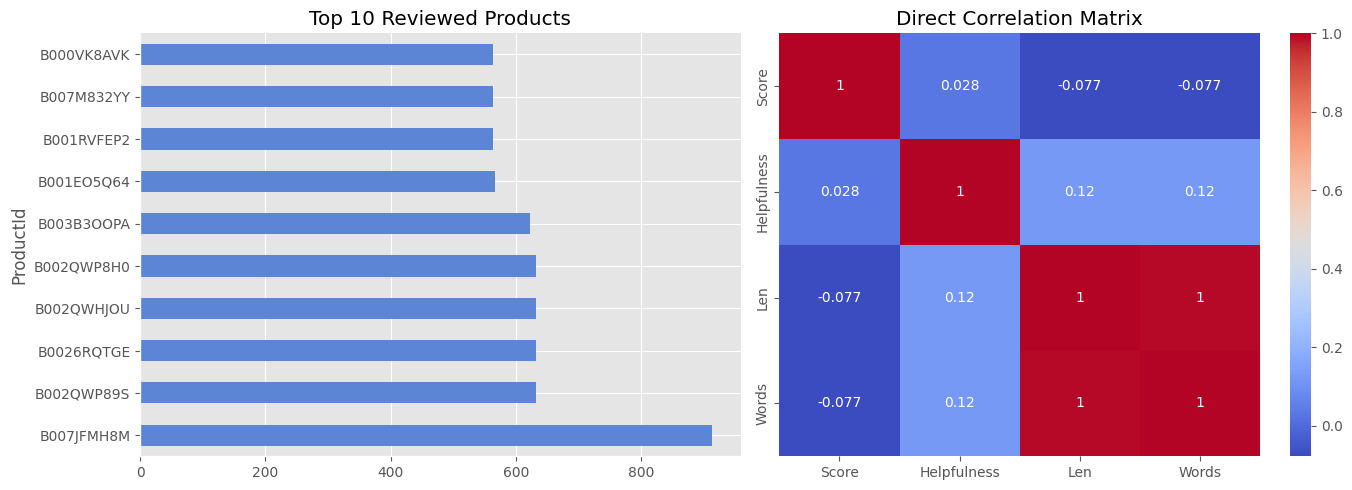

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Top 10 Products
ax = axes[0]
data["ProductId"].value_counts().head(10).plot(kind='barh', color=C["bar"], ax=ax)
ax.set_title("Top 10 Reviewed Products")


# 2. Correlation (Subset only for the matrix)
ax = axes[1]
# Creating a temp df just for the heatmap calculation
temp_corr = pd.DataFrame({
    "Score": data["Score"],
    "Helpfulness": data["HelpfulnessNumerator"] / data["HelpfulnessDenominator"].replace(0, 1),
    "Len": data["Text"].str.len(),
    "Words": data["Text"].apply(lambda x: len(str(x).split()))
})
sns.heatmap(temp_corr.corr(), annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Direct Correlation Matrix")

plt.tight_layout()
plt.show()

# Basic NLTK

In [11]:
example = data['Text'][80]
example

"This peppermint stick is delicious and fun to eat.  My dad got me one for Christmas because he remembered me having a similar one when I was a little girl.  I'm 30 now and I love it!"

In [12]:
# Split sentence into a part of each word (token).
tokens = nltk.word_tokenize(example)
tokens

['This',
 'peppermint',
 'stick',
 'is',
 'delicious',
 'and',
 'fun',
 'to',
 'eat',
 '.',
 'My',
 'dad',
 'got',
 'me',
 'one',
 'for',
 'Christmas',
 'because',
 'he',
 'remembered',
 'me',
 'having',
 'a',
 'similar',
 'one',
 'when',
 'I',
 'was',
 'a',
 'little',
 'girl',
 '.',
 'I',
 "'m",
 '30',
 'now',
 'and',
 'I',
 'love',
 'it',
 '!']

In [13]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [14]:
# part of speech tagging 
tagged = nltk.pos_tag(tokens)
tagged

[('This', 'DT'),
 ('peppermint', 'NN'),
 ('stick', 'NN'),
 ('is', 'VBZ'),
 ('delicious', 'JJ'),
 ('and', 'CC'),
 ('fun', 'NN'),
 ('to', 'TO'),
 ('eat', 'VB'),
 ('.', '.'),
 ('My', 'PRP$'),
 ('dad', 'NN'),
 ('got', 'VBD'),
 ('me', 'PRP'),
 ('one', 'CD'),
 ('for', 'IN'),
 ('Christmas', 'NNP'),
 ('because', 'IN'),
 ('he', 'PRP'),
 ('remembered', 'VBD'),
 ('me', 'PRP'),
 ('having', 'VBG'),
 ('a', 'DT'),
 ('similar', 'JJ'),
 ('one', 'CD'),
 ('when', 'WRB'),
 ('I', 'PRP'),
 ('was', 'VBD'),
 ('a', 'DT'),
 ('little', 'JJ'),
 ('girl', 'NN'),
 ('.', '.'),
 ('I', 'PRP'),
 ("'m", 'VBP'),
 ('30', 'CD'),
 ('now', 'RB'),
 ('and', 'CC'),
 ('I', 'PRP'),
 ('love', 'VBP'),
 ('it', 'PRP'),
 ('!', '.')]

In [15]:
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [16]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  This/DT
  peppermint/NN
  stick/NN
  is/VBZ
  delicious/JJ
  and/CC
  fun/NN
  to/TO
  eat/VB
  ./.
  My/PRP$
  dad/NN
  got/VBD
  me/PRP
  one/CD
  for/IN
  (PERSON Christmas/NNP)
  because/IN
  he/PRP
  remembered/VBD
  me/PRP
  having/VBG
  a/DT
  similar/JJ
  one/CD
  when/WRB
  I/PRP
  was/VBD
  a/DT
  little/JJ
  girl/NN
  ./.
  I/PRP
  'm/VBP
  30/CD
  now/RB
  and/CC
  I/PRP
  love/VBP
  it/PRP
  !/.)


# VADER Sentiment Scoring 
Using the `SentimentIntensityAnalyzer` to get the `neutral/negative/positive` scores of the text.
- This uses a "bag of words" approach:
  1. Stop words are removed.
  2. Each word is scored and combined to a total score.

In [17]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [18]:
sia.polarity_scores("I am so happy")

{'neg': 0.0, 'neu': 0.334, 'pos': 0.666, 'compound': 0.6115}

In [19]:
sia.polarity_scores("Cooking microwave pizzas, yummy")

{'neg': 0.0, 'neu': 0.469, 'pos': 0.531, 'compound': 0.5267}

In [20]:
# Let's test the example 
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.723, 'pos': 0.277, 'compound': 0.9098}

In [21]:
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Apply the polarity score on the whole dataset

In [22]:
# Run the polarity score on the entire dataset
result = {}
for i, row in tqdm(data.iterrows(), total = len(data)):
    text = row['Text']
    myid = row['Id']
    result[myid] = sia.polarity_scores(text)

  0%|          | 0/568454 [00:00<?, ?it/s]

In [23]:
vaders = pd.DataFrame(result).T
vaders = vaders.reset_index().rename(columns = {"index": "Id"})
vaders = vaders.merge(data, how = "left")

In [24]:
# Now we have sentiment score and metadata
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Plot VADERS results

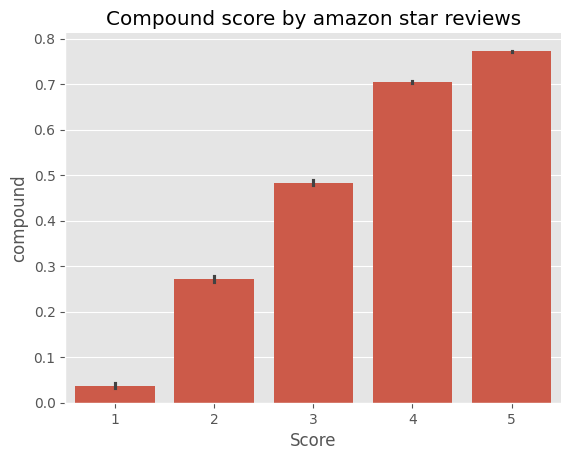

In [25]:
ax = sns.barplot(data = vaders, x = 'Score', y = 'compound')
ax.set_title("Compound score by amazon star reviews")
plt.show()

## Plot the compound category 

### Positive

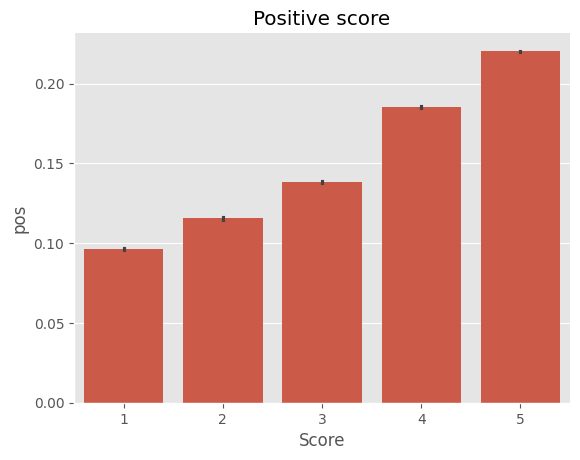

In [26]:
ax = sns.barplot(vaders, x = 'Score', y = 'pos')
ax.set_title('Positive score')
plt.show()

### Neutral 

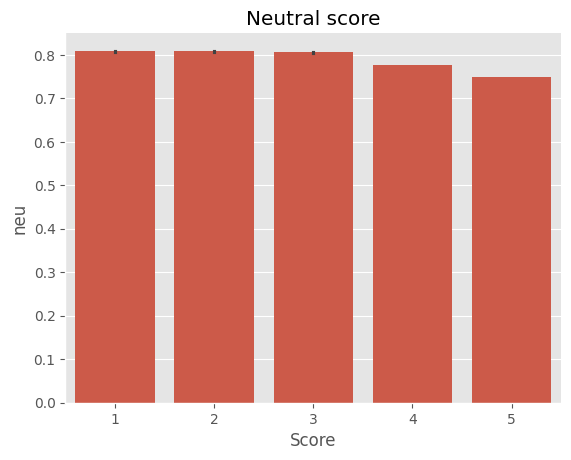

In [27]:
ax = sns.barplot(vaders, x = 'Score', y = 'neu')
ax.set_title('Neutral score')
plt.show()

### Negative

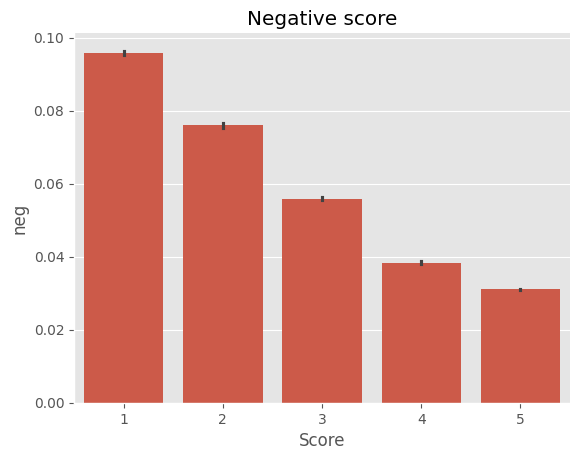

In [28]:
ax = sns.barplot(vaders, x = 'Score', y = 'neg')
ax.set_title('Negative score')
plt.show()

# Huggingface Transformer 🤗

# RoBERTa Pretrained Model 
- Use a model trained of a large corpus of data
- Transformer model accounts for the words but also the context related to the other words.

In [29]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [30]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [31]:
print(example)

This peppermint stick is delicious and fun to eat.  My dad got me one for Christmas because he remembered me having a similar one when I was a little girl.  I'm 30 now and I love it!


In [32]:
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.723, 'pos': 0.277, 'compound': 0.9098}

#### Test on example 

In [33]:
# Run for the roberta Model on the example
encoded_text = tokenizer(example, return_tensors = 'pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
scores_dict

{'roberta_neg': np.float32(0.0015721087),
 'roberta_neu': np.float32(0.0062695034),
 'roberta_pos': np.float32(0.9921584)}

#### Test on the whole entire dataset

In [34]:
def polarity_scores_roberta(example):
    
    encoded_text = tokenizer(example, return_tensors = 'pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [35]:
# Let's take sample data because of time complexity
data = data.head(5000)

In [36]:
result = {}
for i, row in tqdm(data.iterrows(), total = len(data)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result, **roberta_result}
        result[myid] = both
    except RuntimeError:
        print(f"Broke for id {myid}")

  0%|          | 0/5000 [00:00<?, ?it/s]

Broke for id 83
Broke for id 187
Broke for id 529
Broke for id 540
Broke for id 746
Broke for id 863
Broke for id 1053
Broke for id 1070
Broke for id 1156
Broke for id 1321
Broke for id 1375
Broke for id 1498
Broke for id 1575
Broke for id 1796
Broke for id 1826
Broke for id 2169
Broke for id 2248
Broke for id 2476
Broke for id 2492
Broke for id 2584
Broke for id 2610
Broke for id 2897
Broke for id 2898
Broke for id 2902
Broke for id 2928
Broke for id 2942
Broke for id 2944
Broke for id 2947
Broke for id 2948
Broke for id 3022
Broke for id 3023
Broke for id 3025
Broke for id 3306
Broke for id 3788
Broke for id 3969
Broke for id 4107
Broke for id 4110
Broke for id 4307
Broke for id 4316
Broke for id 4408
Broke for id 4483
Broke for id 4512
Broke for id 4553
Broke for id 4583


In [37]:
results_df = pd.DataFrame(result).T
results_df = results_df.reset_index().rename(columns = {'index': 'Id'})
results_df = results_df.merge(data, how = 'left')

In [38]:
results_df.head()

,Id,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,0.009624,0.049980,0.940395,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,0.508986,0.452414,0.038600,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,0.003229,0.098067,0.898704,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,0.002295,0.090219,0.907486,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,0.001635,0.010302,0.988063,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Compare Score between models 

In [39]:
results_df.columns

Index(['Id', 'neg', 'neu', 'pos', 'compound', 'roberta_neg', 'roberta_neu',
       'roberta_pos', 'ProductId', 'UserId', 'ProfileName',
       'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time',
       'Summary', 'Text'],
      dtype='object')

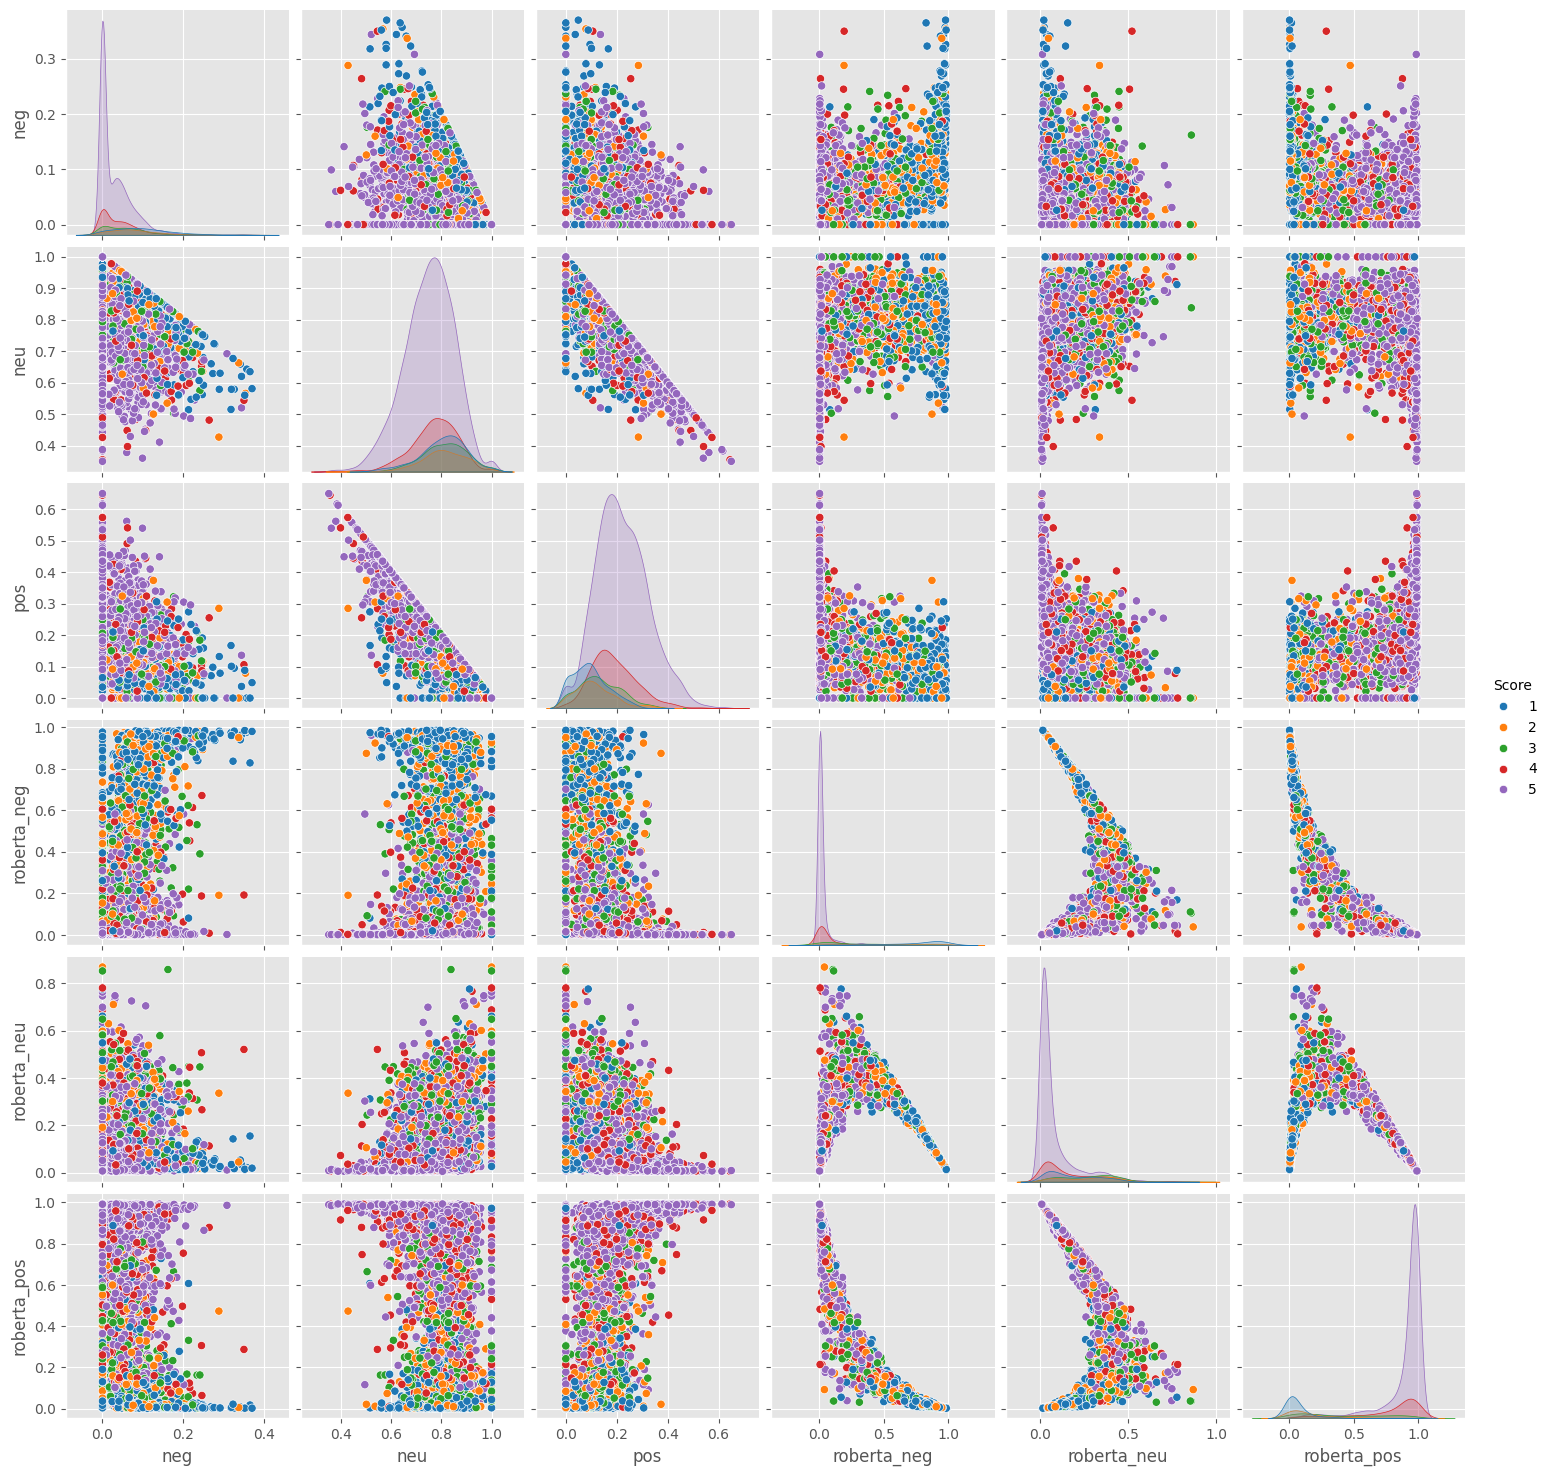

In [40]:
sns.pairplot(results_df, vars = ['neg', 'neu', 'pos', 
                                'roberta_neg', 'roberta_neu',
       'roberta_pos'], 
            hue = 'Score',
            palette = 'tab10')
plt.show()

## Review Exmaples
- Positive = 1-Star Reviews
- Negative = 5-Star Reviews

## Positive 1-Star Review

### RoBERTa model example 

In [41]:
results_df[results_df['Score']== 1].sort_values('roberta_pos', ascending = False)['Text'].values[0]

'Bisquick GF is easy to use. Pancakes and muffins are very<br />tasty. The product is quick and easy to use. It makes my day.  Gram'

### VADER model example 

In [42]:
results_df[results_df['Score'] == 1].sort_values('pos', ascending = False)['Text'].values[0]

"Second ingredient is SUGAR! Need I say more? Make your own bisquit mix, it's super easy!"

## Negative 5-Star Review

### RoBERTa model example 

In [43]:
results_df[results_df['Score'] == 5].sort_values('roberta_neg', ascending = False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

### VADER model example 

In [44]:
results_df[results_df['Score'] == 5].sort_values('neg', ascending = False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

# Transformer Pipeline 
- Quick & easy way to run sentiment predictions

In [45]:
from transformers import pipeline

In [46]:
sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [47]:
# Let's check the pipeline 
sentiment_pipeline("Your shipment has been delayed")

[{'label': 'NEGATIVE', 'score': 0.9979694485664368}]

In [48]:
sentiment_pipeline("Your shipment is ready for collection")

[{'label': 'POSITIVE', 'score': 0.8635572195053101}]

## Create a Baseline for True Labels

In [49]:
def map_true_score(score):
    if score < 3:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [50]:
results_df['True_label'] = results_df['Score'].apply(map_true_score)

In [51]:
results_df['True_label'].value_counts()

True_label
Positive    3819
Negative     746
Neutral      391
Name: count, dtype: int64

## Standardize Model Predictions

### For VADER:
- VADER outputs a compound score between -1 and 1. Standard practice is to use `-0.05` and `0.05` as thresholds.

In [52]:
def map_vader_score(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [53]:
# Assuming your VADER compound scores are in a column named 'vader_compound'
results_df['Vader_Prediction'] = results_df['compound'].apply(map_vader_score)

In [54]:
results_df['Vader_Prediction'].value_counts()

Vader_Prediction
Positive    4313
Negative     529
Neutral      114
Name: count, dtype: int64

### For RoBERTa:
- Depending on how you saved the `RoBERTa` outputs, you'll need to map its labels. If your pipeline output directly gave you `"NEGATIVE", "POSITIVE", etc`., just ensure the capitalization matches the true labels.

In [55]:
# 1. Specify the columns containing RoBERTa's probability outputs
roberta_cols = ['roberta_neg', 'roberta_neu', 'roberta_pos']

# 2. Use idxmax(axis=1) to find the column name that has the highest value for each row
highest_prob_col = results_df[roberta_cols].idxmax(axis=1)

# 3. Create a dictionary to map those raw column names to your clean labels
roberta_mapping = {
    'roberta_neg': 'Negative',
    'roberta_neu': 'Neutral',
    'roberta_pos': 'Positive'
}

# 4. Apply the mapping to create your final prediction column
results_df['Roberta_Prediction'] = highest_prob_col.map(roberta_mapping)

In [56]:
results_df['Roberta_Prediction'].value_counts()

Roberta_Prediction
Positive    3857
Negative     778
Neutral      321
Name: count, dtype: int64

## Classification Report 

In [57]:
# VADER Evaluation
print("--- VADER Classification Report ---")
print(classification_report(results_df['True_label'], results_df['Vader_Prediction']))

--- VADER Classification Report ---
              precision    recall  f1-score   support

    Negative       0.58      0.41      0.48       746
     Neutral       0.18      0.05      0.08       391
    Positive       0.84      0.95      0.89      3819

    accuracy                           0.80      4956
   macro avg       0.54      0.47      0.49      4956
weighted avg       0.75      0.80      0.77      4956



In [58]:
# RoBERTa Evaluation
print("--- RoBERTa Classification Report ---")
print(classification_report(results_df['True_label'], results_df['Roberta_Prediction']))

--- RoBERTa Classification Report ---
              precision    recall  f1-score   support

    Negative       0.72      0.75      0.74       746
     Neutral       0.25      0.20      0.22       391
    Positive       0.93      0.94      0.93      3819

    accuracy                           0.85      4956
   macro avg       0.63      0.63      0.63      4956
weighted avg       0.84      0.85      0.85      4956



## Confusion Matrix

In [59]:
def plot_confusion_matrix(y_true, y_pred, title):
    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=['Negative', 'Neutral', 'Positive'])
    
    # Plot using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Neutral', 'Positive'], 
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.ylabel('Actual Sentiment (Amazon Score)')
    plt.xlabel('Predicted Sentiment')
    plt.show()

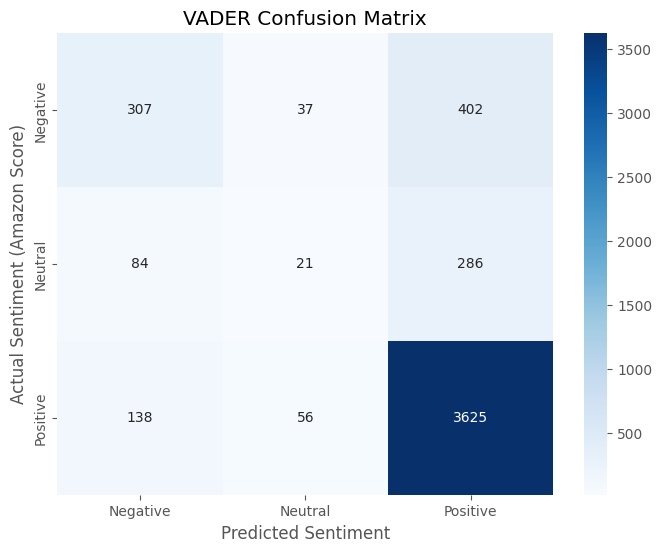

In [60]:
# Generate the plots
plot_confusion_matrix(results_df['True_label'], results_df['Vader_Prediction'], "VADER Confusion Matrix")

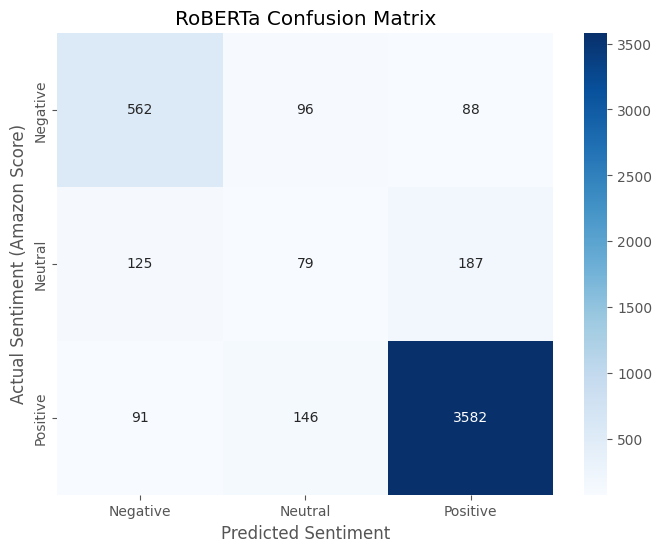

In [61]:
plot_confusion_matrix(results_df['True_label'], results_df['Roberta_Prediction'], "RoBERTa Confusion Matrix")

## F1-Score Comparison Bar Chart

In [62]:
# Get classification reports as dictionaries to extract numbers
report_vader = classification_report(results_df['True_label'], results_df['Vader_Prediction'], output_dict=True)
report_roberta = classification_report(results_df['True_label'], results_df['Roberta_Prediction'], output_dict=True)

# Extract F1-scores for each class
f1_scores = {
    'Class': ['Negative', 'Neutral', 'Positive'],
    'VADER': [report_vader['Negative']['f1-score'], 
              report_vader['Neutral']['f1-score'], 
              report_vader['Positive']['f1-score']],
    'RoBERTa': [report_roberta['Negative']['f1-score'], 
                report_roberta['Neutral']['f1-score'], 
                report_roberta['Positive']['f1-score']]
}

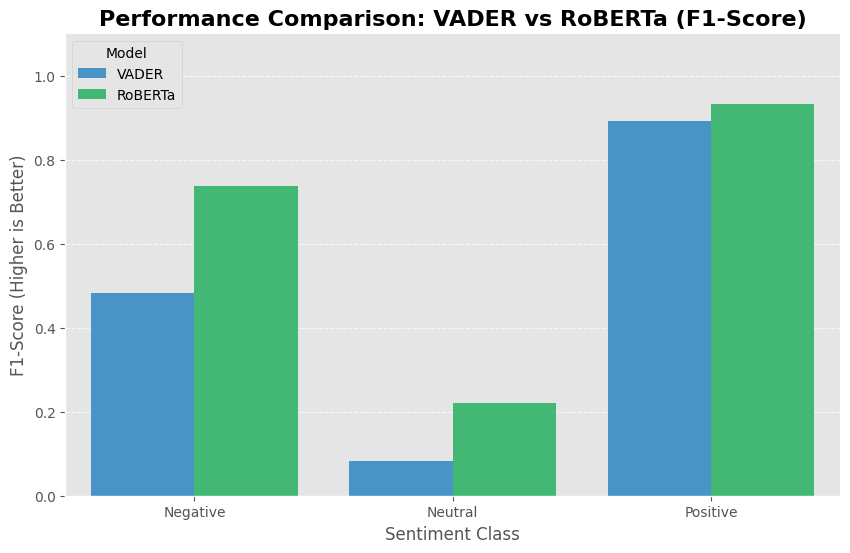

In [63]:
# Convert to a DataFrame suitable for Seaborn plotting
df_metrics = pd.DataFrame(f1_scores)
df_melted = df_metrics.melt(id_vars='Class', var_name='Model', value_name='F1-Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Class', y='F1-Score', hue='Model', palette=['#3498db', '#2ecc71'])
plt.title('Performance Comparison: VADER vs RoBERTa (F1-Score)', fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('F1-Score (Higher is Better)')
plt.xlabel('Sentiment Class')
plt.legend(title='Model', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()